# What is R-Group Decomposition?

R-Group Decomposition (RGD) is a cheminformatics technique used to identify and compare the substituents (R-groups) attached to a common molecular core.

Instead of comparing complete molecules, RGD separates each molecule into:

- A common core (scaffold)
- Variable substituent groups (R-groups)

This enables medicinal chemists to study how changes in substituents influence biological activity.

## Why Do We Need R-Group Decomposition?

During lead optimization, researchers often synthesize many molecules sharing the same core structure but differing in their substituents.

R-Group Decomposition helps answer questions such as:

- Which substituent improves potency?
- Which substituent reduces toxicity?
- Which substituent increases solubility?
- Which substituent enhances selectivity?

By separating the common scaffold from the variable R-groups, Structure–Activity Relationships (SAR) become much easier to interpret.

# How does RDKit know what is the Core and what is an R-group?

RDKit does NOT automatically know the core.
You must provide the core (scaffold) to RDKit.
Then RDKit determines what remains attached to that core. Those remaining parts are the R-groups.

In [1]:
# Example
# Import Libraries

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdRGroupDecomposition
import pandas as pd

In [2]:
# Create Molecules

molecules = [
    Chem.MolFromSmiles("Cc1ccccc1"),   # Toluene
    Chem.MolFromSmiles("Oc1ccccc1"),   # Phenol
    Chem.MolFromSmiles("Nc1ccccc1"),   # Aniline
    Chem.MolFromSmiles("Clc1ccccc1")   # Chlorobenzene
]

names = [
    "Toluene",
    "Phenol",
    "Aniline",
    "Chlorobenzene"
]

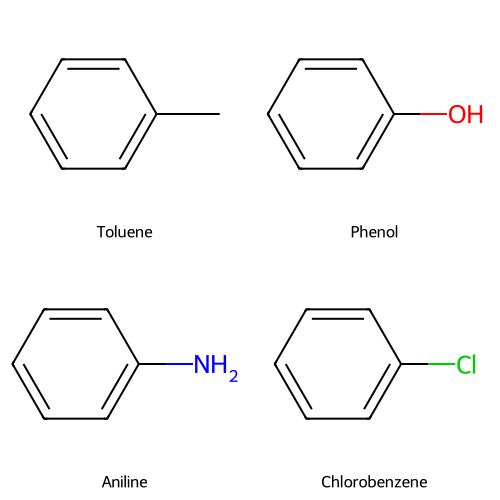

In [3]:
# Display Molecule

Draw.MolsToGridImage(
    molecules,
    legends=names,
    molsPerRow=2,
    subImgSize=(250,250)
)

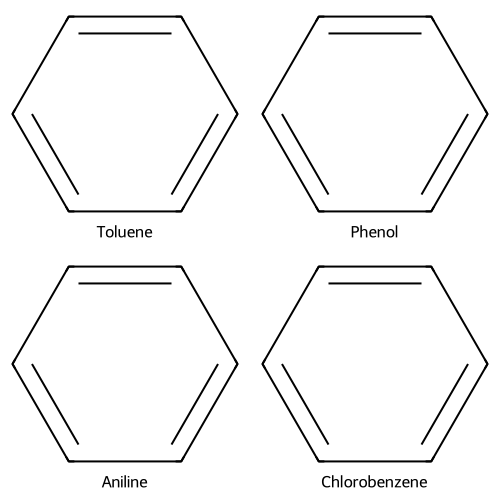

In [4]:
# Generate Murcko Scaffold

from rdkit.Chem.Scaffolds import MurckoScaffold

scaffolds = []

for mol in molecules:
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    scaffolds.append(scaffold)

Draw.MolsToGridImage(
    scaffolds,
    legends=names,
    molsPerRow=2,
    subImgSize=(250,250)
)



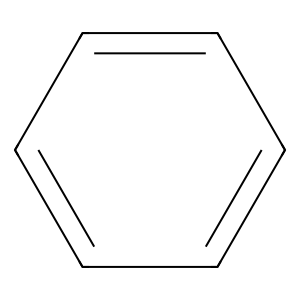

In [5]:
# Use one Scaffold as the Core

core = scaffolds[0]

Draw.MolToImage(core)

In [6]:
# Perform R-Group Decomposition

groups, unmatched = rdRGroupDecomposition.RGroupDecompose(
    [core],
    molecules,
    asSmiles=True
)

df = pd.DataFrame(groups)

df.insert(0, "Molecule", names)

df

,Molecule,Core,R1
0,Toluene,c1ccc([*:1])cc1,C[*:1]
1,Phenol,c1ccc([*:1])cc1,O[*:1]
2,Aniline,c1ccc([*:1])cc1,N[*:1]
3,Chlorobenzene,c1ccc([*:1])cc1,Cl[*:1]


# One Important Note

This works here because all four molecules belong to the same scaffold family.
If one molecule had a different scaffold, for example:
Caffeine
Morphine
their Murcko scaffolds would be different, and you couldn't simply use scaffolds[0] as the common core for all molecules. In that situation, you would first group molecules by scaffold (or use MCS within a scaffold family) before performing R-group decomposition.

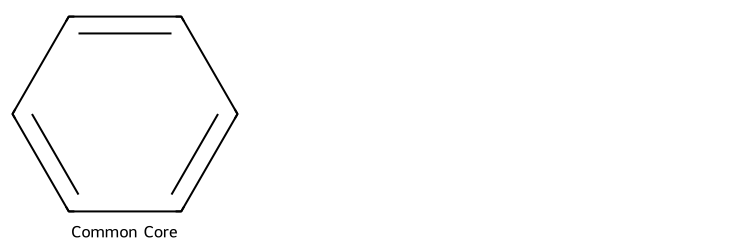

In [7]:
# Show the actual Structure

Draw.MolsToGridImage(
    [core],
    legends=["Common Core"],
    subImgSize=(250,250)
)

## Note

RDKit returns R-groups using attachment-point notation (e.g., C[*:1], O[*:1], N[*:1], Cl[*:1]) rather than complete molecular structures.

These R-groups are molecular fragments, not standalone molecules. The symbol [*:1] represents the attachment point where the fragment connects to the common core.

Since these fragments are incomplete chemical structures, RDKit does not directly display them as isolated molecules in a meaningful way.

In practice, R-Group Decomposition is primarily used to generate SAR tables that relate different R-groups to biological activity rather than to visualize the isolated R-group structures.

# Tip: 
To understand the decomposition, compare the original molecules with the common core. The atoms present in the original molecule but absent from the common core correspond to the identified R-group.